In [191]:
#Import Libraries
import numpy as np 
import pandas as pd

#Import Split and Cross Validation
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

#Import Metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

#Import LightGBM
import lightgbm as lgb

In [192]:
#Read in Data
df = pd.read_csv('/Users/deepesh.b.verma/Documents/data-science/summer26-patient-length-of-stay/cleaned_data/PUDF_base1_1q2016_cleaned.csv')

In [193]:
#Provides a random sample of the data.
df.sample(10,random_state=42)


,RECORD_ID,DISCHARGE,THCIC_ID,TYPE_OF_ADMISSION,SOURCE_OF_ADMISSION,PAT_STATE,PAT_ZIP,PAT_COUNTRY,PAT_COUNTY,PUBLIC_HEALTH_REGION,...,CODE_17,CODE_18,CODE_19,CODE_20,CODE_21,CODE_22,PAT_RURAL,PROVIDER_ZIP,PROVIDER_RURAL,PAT2PROV_DISTANCE
323621,120160965862,2016Q1,724700,1.0,1,TX,77354,US,339.0,6.0,...,0,0,0,0,1,0,0,77070,0,28.524323
125434,120160731894,2016Q1,19000,4.0,5,TX,78521,US,61.0,11.0,...,0,0,0,0,1,0,0,78526,0,5.583455
99098,120160702505,2016Q1,634000,4.0,5,TX,78239,US,29.0,8.0,...,0,0,0,0,1,0,0,78229,0,20.091491
228354,120160852248,2016Q1,453000,1.0,1,TX,77968,US,469.0,8.0,...,0,1,0,0,0,0,1,77901,1,21.832392
91129,120160692543,2016Q1,105,3.0,2,TX,77095,US,201.0,6.0,...,0,0,0,0,0,0,0,77030,0,31.856710
359541,120161009661,2016Q1,497000,1.0,1,TX,78705,US,453.0,7.0,...,0,1,0,0,0,0,0,78705,0,0.000000
653526,120165534170,2016Q1,459000,2.0,2,TX,77067,US,201.0,6.0,...,0,0,0,0,0,0,0,77030,0,28.299789
257028,120160883822,2016Q1,235000,1.0,1,TX,76126,US,439.0,3.0,...,0,0,0,0,0,0,0,76104,0,23.228449
439543,120161107186,2016Q1,802003,1.0,1,TX,78576,US,215.0,11.0,...,0,0,0,0,0,0,0,78503,0,22.445936
655696,120165536738,2016Q1,459000,1.0,1,TX,77020,US,201.0,6.0,...,0,0,0,0,0,0,0,77030,0,11.714748


In [194]:
#Information about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 671138 entries, 0 to 671137
Data columns (total 44 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   RECORD_ID             671138 non-null  int64  
 1   DISCHARGE             671138 non-null  str    
 2   THCIC_ID              671138 non-null  int64  
 3   TYPE_OF_ADMISSION     671138 non-null  float64
 4   SOURCE_OF_ADMISSION   671138 non-null  str    
 5   PAT_STATE             671138 non-null  str    
 6   PAT_ZIP               671138 non-null  int64  
 7   PAT_COUNTRY           671138 non-null  str    
 8   PAT_COUNTY            671138 non-null  float64
 9   PUBLIC_HEALTH_REGION  671138 non-null  float64
 10  PAT_STATUS            671138 non-null  int64  
 11  SEX_CODE              671138 non-null  str    
 12  RACE                  671138 non-null  int64  
 13  ETHNICITY             671138 non-null  int64  
 14  ADMIT_WEEKDAY         671138 non-null  float64
 15  LENGTH_OF_S

In [195]:
#Creates an additional column for prolonged stays
df['PROLONGED'] = np.where(df['LENGTH_OF_STAY'] >= 30, 1, 0)

#Creates an additional column for number of codes
df['NUM_CODES'] = df.iloc[:, 18:39].sum(axis=1)

#Creates an additional column for stratification
df['strata'] = df['DISCHARGE'].astype(str) + '_' + df['PAT_RURAL'].astype(str) # + '_' + df['PROLONGED'].astype(str)



In [196]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 671138 entries, 0 to 671137
Data columns (total 47 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   RECORD_ID             671138 non-null  int64  
 1   DISCHARGE             671138 non-null  str    
 2   THCIC_ID              671138 non-null  int64  
 3   TYPE_OF_ADMISSION     671138 non-null  float64
 4   SOURCE_OF_ADMISSION   671138 non-null  str    
 5   PAT_STATE             671138 non-null  str    
 6   PAT_ZIP               671138 non-null  int64  
 7   PAT_COUNTRY           671138 non-null  str    
 8   PAT_COUNTY            671138 non-null  float64
 9   PUBLIC_HEALTH_REGION  671138 non-null  float64
 10  PAT_STATUS            671138 non-null  int64  
 11  SEX_CODE              671138 non-null  str    
 12  RACE                  671138 non-null  int64  
 13  ETHNICITY             671138 non-null  int64  
 14  ADMIT_WEEKDAY         671138 non-null  float64
 15  LENGTH_OF_S

In [197]:
#Find count for each unique value in the DISCHARGE column.
df['DISCHARGE'].value_counts()


DISCHARGE
2016Q1    670683
2015Q4       455
Name: count, dtype: int64

In [198]:
#Remove rows with DISCHARGE values of 2015Q4
df = df[df['DISCHARGE'] != '2015Q4']

#Check the unique values in the DISCHARGE column.
df['DISCHARGE'].value_counts()

DISCHARGE
2016Q1    670683
Name: count, dtype: int64

In [199]:
#Select features we're using in the model
features = (
    df.columns[11:17].tolist() +
    df.columns[18:40].tolist() + 
    df.columns[40:41].tolist() +
    df.columns[42:46].tolist()
)

df[features].info()

<class 'pandas.DataFrame'>
RangeIndex: 670683 entries, 0 to 670682
Data columns (total 33 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX_CODE           670683 non-null  str    
 1   RACE               670683 non-null  int64  
 2   ETHNICITY          670683 non-null  int64  
 3   ADMIT_WEEKDAY      670683 non-null  float64
 4   LENGTH_OF_STAY     670683 non-null  float64
 5   PAT_AGE            670683 non-null  int64  
 6   CODE_1             670683 non-null  int64  
 7   CODE_2             670683 non-null  int64  
 8   CODE_3             670683 non-null  int64  
 9   CODE_4             670683 non-null  int64  
 10  CODE_5             670683 non-null  int64  
 11  CODE_6             670683 non-null  int64  
 12  CODE_7             670683 non-null  int64  
 13  CODE_8             670683 non-null  int64  
 14  CODE_9             670683 non-null  int64  
 15  CODE_10            670683 non-null  int64  
 16  CODE_11      

In [200]:
#Define input (x) and output (y) data for the model.
x = df[features]
x = x.drop(columns=['LENGTH_OF_STAY','PROLONGED'])
y = df['LENGTH_OF_STAY']

#Split the data into training and testing sets.
x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [201]:
#Fix data type to be categories instead of strings.
cat_cols = ['SEX_CODE']

x_train[cat_cols] = x_train[cat_cols].astype('category')
x_test[cat_cols]  = x_test[cat_cols].astype('category')

In [202]:
#Imports LightGBM
from lightgbm import LGBMRegressor

#Initializes the model.
model = LGBMRegressor(
    n_estimators=2000,          
    learning_rate=0.05,       
    num_leaves=127,             
    max_depth=7,                

    min_child_samples=100,      
    reg_alpha=0.1,              
    reg_lambda=0.1,             

    subsample=0.8,              
    subsample_freq=1,          
    colsample_bytree=0.8,      

    n_jobs=-1,              
    device='cpu',              

    random_state=42
)

#Train the model.
model.fit(
    x_train,
    y_train,
    eval_set=[(x_test,y_test)],
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 357
[LightGBM] [Info] Number of data points in the train set: 536546, number of used features: 29
[LightGBM] [Info] Start training from score 5.330399
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

,boosting_type,'gbdt'
,num_leaves,127
,max_depth,7
,learning_rate,0.05
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

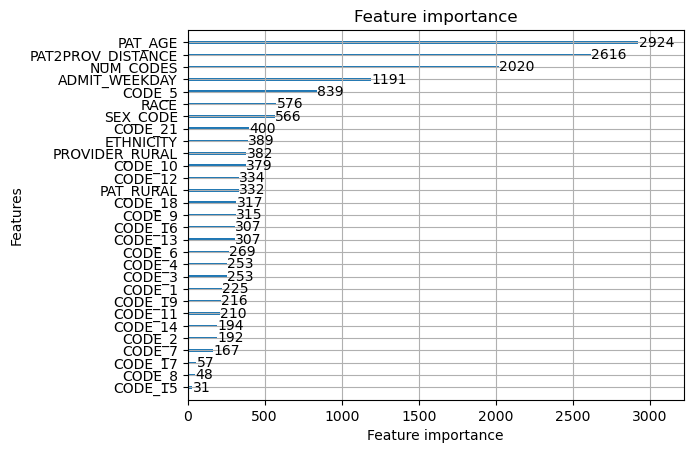

In [203]:
lgb.plot_importance(model)

In [204]:
print('Training accuracy {:.4f}'.format(model.score(x_train,y_train)))
print('Testing accuracy {:.4f}'.format(model.score(x_test,y_test)))

Training accuracy 0.2415
Testing accuracy 0.2010


<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='l2'>

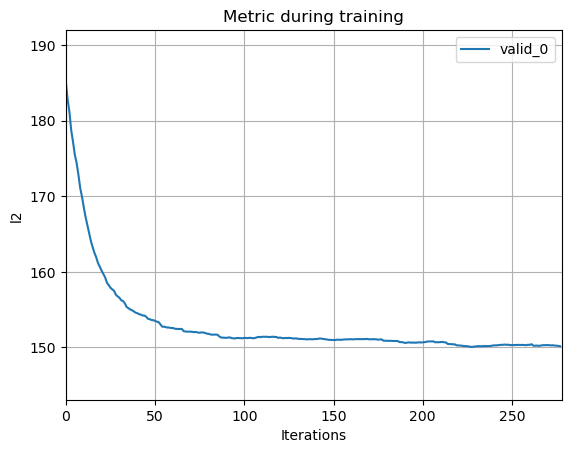

In [205]:
lgb.plot_metric(model)

In [206]:
y_pred = model.predict(x_test)

In [207]:
rmse_val = root_mean_squared_error(y_test,y_pred)
mse_val = mean_squared_error(y_test,y_pred)

In [208]:
print("RMSE:",rmse_val)
print("MSE:",mse_val)

RMSE: 12.250144971472366
MSE: 150.0660518220897


In [209]:
#Define input (xs) and output (ys) data for the model using stratification
xs = df[features]
xs = xs.drop(columns=['LENGTH_OF_STAY','PROLONGED'])
ys = df['LENGTH_OF_STAY']

#Split the data into training and testing sets.
xs_train, xs_test, ys_train, ys_test = train_test_split(xs,
                                                    ys,
                                                    test_size=0.2,
                                                    stratify = df['strata'],
                                                    random_state=42)

In [210]:
xs_train[cat_cols] = xs_train[cat_cols].astype('category')
xs_test[cat_cols]  = xs_test[cat_cols].astype('category')

In [211]:
# Create the StratifiedKFold
strata_train = df.loc[xs_train.index, 'strata'] #Indexes strata with training data

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [212]:
oof_preds    = np.zeros(len(xs_train))  # out-of-fold predictions
test_preds   = np.zeros(len(xs_test))   # averaged test predictions
rmse_scores  = []
models       = [] #stores each fold model

# Fit the model for each fold
for fold, (train_idx, valid_idx) in enumerate(skf.split(xs_train, strata_train)):
    
    #Slice
    xs_tr = xs_train.iloc[train_idx].copy()
    xs_val = xs_train.iloc[valid_idx].copy()
    ys_tr = ys_train.iloc[train_idx]
    ys_val = ys_train.iloc[valid_idx]

   #Initializes the model.
    fold_model = LGBMRegressor(
        n_estimators=2000,          
        learning_rate=0.05,       
        num_leaves=127,             
        max_depth=7,                

        min_child_samples=100,      
        reg_alpha=0.1,              
        reg_lambda=0.1,             

        subsample=0.8,              
        subsample_freq=1,          
        colsample_bytree=0.8,      

        n_jobs=-1,              
        device='cpu',              

        random_state=42
    )

    fold_model.fit(
            xs_tr,
            ys_tr,
            eval_set=[(xs_val,ys_val)],
            categorical_feature=cat_cols,
            callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)]
            )

    # Find predictions and store rmses  
    oof_preds[valid_idx]  = fold_model.predict(xs_val)
    test_preds         += fold_model.predict(xs_test) / skf.n_splits

    #Scores
    rmse = root_mean_squared_error(ys_val, oof_preds[valid_idx])
    rmse_scores.append(rmse)
    models.append(fold_model)
    print(f"Fold {fold + 1} RMSE: {rmse:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071797 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 357
[LightGBM] [Info] Number of data points in the train set: 482891, number of used features: 29
[LightGBM] [Info] Start training from score 5.346217
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

In [213]:
# OOF RMSE is your most honest estimate of generalisation error
oof_rmse = root_mean_squared_error(ys_train, oof_preds)

print(f"Best RMSE: {np.min(rmse_scores):.4f}")
print(f"\nPer-fold RMSE:  {[round(s, 4) for s in rmse_scores]}")
print(f"Mean RMSE:      {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"OOF RMSE:       {oof_rmse:.4f}")

Best RMSE: 8.0947

Per-fold RMSE:  [8.9245, 9.2768, 17.3359, 12.7229, 15.2994, 18.8801, 10.9487, 14.0157, 8.0947, 13.5138]
Mean RMSE:      12.9012 ± 3.4450
OOF RMSE:       13.3533


In [214]:
final_model = LGBMRegressor(    # --- Core structure ---
        n_estimators = int(np.mean([m.best_iteration_ for m in models])),          # high ceiling; let early stopping decide
        learning_rate=0.05,         # slower learning = better generalisation
        num_leaves=127,             # 2^max_depth - 1 is a good rule of thumb
        max_depth=7,                # moderate depth for 33 features

        # --- Regularisation ---
        min_child_samples=100,      # higher = more conservative splits (good for 600k rows)
        reg_alpha=0.1,              # L1: encourages sparsity
        reg_lambda=0.1,             # L2: penalises large weights

        # --- Subsampling (speed + regularisation) ---
        subsample=0.8,              # use 80% of rows per tree
        subsample_freq=1,           # apply subsampling every iteration
        colsample_bytree=0.8,       # use 80% of features per tree

        # --- Speed ---
        n_jobs=-1,                  # use all cores
        device='cpu',               # swap to 'gpu' if available

        random_state=42
    )
final_model.fit(xs_train, ys_train, categorical_feature=cat_cols)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054955 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 357
[LightGBM] [Info] Number of data points in the train set: 536546, number of used features: 29
[LightGBM] [Info] Start training from score 5.341514
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,boosting_type,'gbdt'
,num_leaves,127
,max_depth,7
,learning_rate,0.05
,n_estimators,756
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

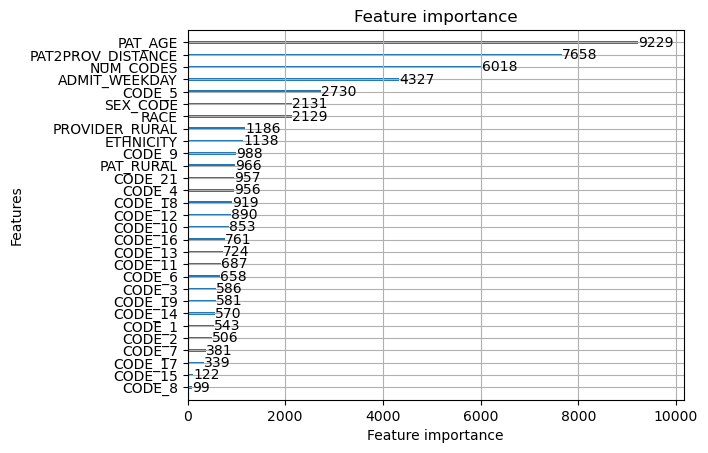

In [215]:
lgb.plot_importance(final_model)

In [216]:
print('Training accuracy {:.4f}'.format(final_model.score(xs_train,ys_train)))
print('Testing accuracy {:.4f}'.format(final_model.score(xs_test,ys_test)))

Training accuracy 0.3363
Testing accuracy 0.1498


In [217]:
final_preds = final_model.predict(xs_test)

In [218]:
rmse_val = root_mean_squared_error(ys_test,final_preds)
mse_val = mean_squared_error(ys_test,final_preds)

In [219]:
print(rmse_val)
print(mse_val)

11.01256657659659
121.27662260397236
